# House Price Prediction using Machine Learning

## Project Overview

The objective of this project is to predict house prices using the Ames Housing Dataset.

Workflow:

1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis
4. Data Cleaning
5. Feature Engineering
6. Model Building
7. Model Evaluation
8. Prediction
9. Save Model

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
df=pd.read_csv("C:\\Users\\Soham Rajapurkar\\OneDrive\\Desktop\\House-Price-Prediction\\data\\AmesHousing.csv")

In [3]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [4]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [5]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [7]:
df.describe(include='object')

,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
count,2930,2930,198,2930,2930,2930,2930,2930,2930,2930,...,2773,2771,2771,2771,2930,13,572,106,2930,2930
unique,7,2,2,4,4,3,5,3,28,9,...,6,3,5,5,3,4,4,5,10,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
freq,2273,2918,120,1859,2633,2927,2140,2789,443,2522,...,1731,1231,2615,2665,2652,4,330,95,2536,2413


In [8]:
missing = df.isnull().sum()

missing = missing[missing>0]

missing.sort_values(ascending=False)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Cond        159
Garage Qual        159
Garage Finish      159
Garage Yr Blt      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Half Bath       2
Bsmt Full Bath       2
BsmtFin SF 1         1
Garage Cars          1
Garage Area          1
Total Bsmt SF        1
Bsmt Unf SF          1
BsmtFin SF 2         1
Electrical           1
dtype: int64

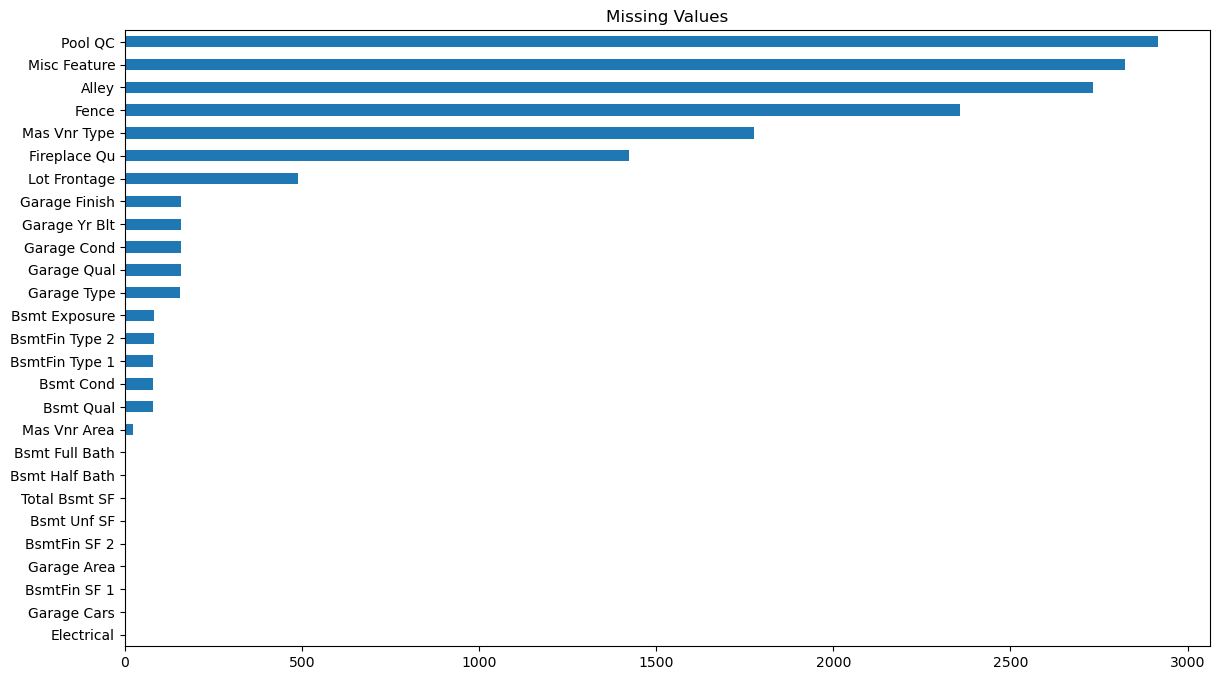

In [9]:
plt.figure(figsize=(14,8))

missing.sort_values().plot(kind='barh')

plt.title("Missing Values")

plt.show()

In [10]:
df.duplicated().sum()

0

In [11]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Cond        159
Garage Qual        159
Garage Finish      159
Garage Yr Blt      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Half Bath       2
Bsmt Full Bath       2
BsmtFin SF 1         1
Garage Cars          1
Garage Area          1
Total Bsmt SF        1
Bsmt Unf SF          1
BsmtFin SF 2         1
Electrical           1
dtype: int64

In [12]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent = missing_percent[missing_percent>0]

missing_percent.sort_values(ascending=False)

Pool QC           99.556314
Misc Feature      96.382253
Alley             93.242321
Fence             80.477816
Mas Vnr Type      60.580205
Fireplace Qu      48.532423
Lot Frontage      16.723549
Garage Cond        5.426621
Garage Qual        5.426621
Garage Finish      5.426621
Garage Yr Blt      5.426621
Garage Type        5.358362
Bsmt Exposure      2.832765
BsmtFin Type 2     2.764505
Bsmt Cond          2.730375
Bsmt Qual          2.730375
BsmtFin Type 1     2.730375
Mas Vnr Area       0.784983
Bsmt Half Bath     0.068259
Bsmt Full Bath     0.068259
BsmtFin SF 1       0.034130
Garage Cars        0.034130
Garage Area        0.034130
Total Bsmt SF      0.034130
Bsmt Unf SF        0.034130
BsmtFin SF 2       0.034130
Electrical         0.034130
dtype: float64

In [13]:
missing_table = pd.DataFrame({

'Missing Values':df.isnull().sum(),

'Percentage':(df.isnull().sum()/len(df))*100

})

missing_table = missing_table[missing_table['Missing Values']>0]

missing_table.sort_values(by='Percentage',ascending=False)


,Missing Values,Percentage
Pool QC,2917,99.556314
Misc Feature,2824,96.382253
Alley,2732,93.242321
Fence,2358,80.477816
Mas Vnr Type,1775,60.580205
Fireplace Qu,1422,48.532423
Lot Frontage,490,16.723549
Garage Cond,159,5.426621
Garage Qual,159,5.426621
Garage Finish,159,5.426621


# House Price Prediction using Machine Learning

## Project Overview

The objective of this project is to predict house prices using the Ames Housing Dataset.

Workflow:

1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis
4. Data Cleaning
5. Feature Engineering
6. Model Building
7. Model Evaluation
8. Prediction
9. Save Model

In [14]:
threshold = 40

drop_columns = missing_percent[missing_percent > threshold].index

drop_columns

Index(['Alley', 'Mas Vnr Type', 'Fireplace Qu', 'Pool QC', 'Fence',
       'Misc Feature'],
      dtype='object')

In [15]:
df.drop(columns=drop_columns,inplace=True)

In [16]:
numerical_columns = df.select_dtypes(include=np.number).columns

categorical_columns = df.select_dtypes(include='object').columns

print("Numerical Columns :",len(numerical_columns))

print("Categorical Columns :",len(categorical_columns))

Numerical Columns : 39
Categorical Columns : 37


In [17]:
for col in numerical_columns:

    df[col].fillna(df[col].median(),inplace=True)

In [18]:
for col in categorical_columns:

    df[col].fillna(df[col].mode()[0],inplace=True)

In [19]:
for col in categorical_columns:

    df[col].fillna(df[col].mode()[0],inplace=True)

In [20]:
df.replace([np.inf,-np.inf],np.nan,inplace=True)

In [21]:
df.isnull().sum().sum()

0

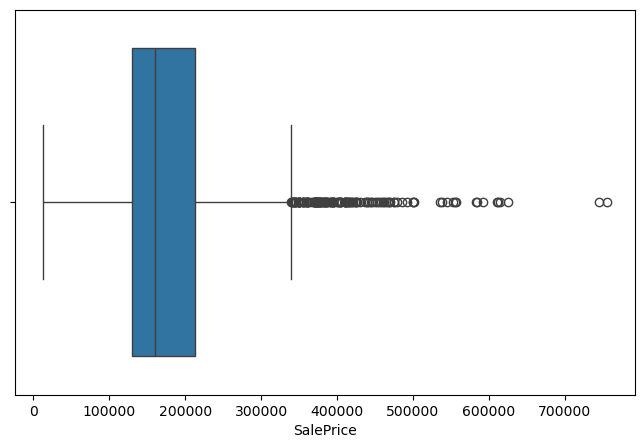

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['SalePrice'])

plt.show()

In [23]:
Q1 = df['SalePrice'].quantile(0.25)

Q3 = df['SalePrice'].quantile(0.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR

upper = Q3+1.5*IQR

df = df[(df['SalePrice']>=lower) & (df['SalePrice']<=upper)]

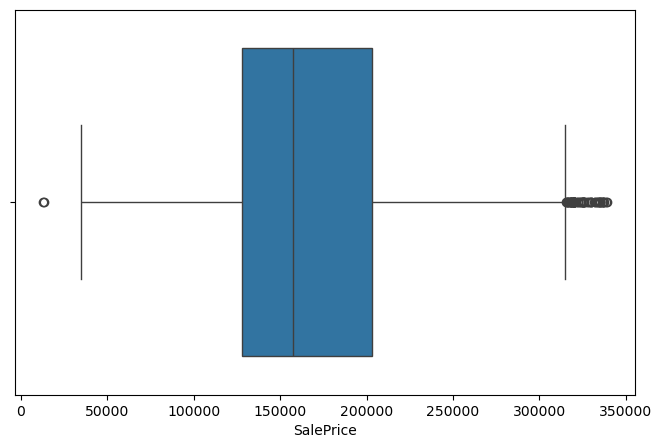

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['SalePrice'])

plt.show()

In [25]:
df.shape

(2793, 76)

In [26]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config',
       'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type',
       'House Style', 'Overall Qual', 'Overall Cond', 'Year Built',
       'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st',
       'Exterior 2nd', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond',
       'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2',
       'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air',
       'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual',
       'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Garage Type',
       'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area',


In [27]:
df["HouseAge"] = df["Yr Sold"] - df["Year Built"]

In [28]:
df["RemodelAge"] = df["Yr Sold"] - df["Year Remod/Add"]

In [29]:
df["TotalBathrooms"] = (
    df["Full Bath"]
    + 0.5 * df["Half Bath"]
    + df["Bsmt Full Bath"]
    + 0.5 * df["Bsmt Half Bath"]
)

In [30]:
df["TotalBathrooms"] = (
    df["Full Bath"]
    + 0.5 * df["Half Bath"]
    + df["Bsmt Full Bath"]
    + 0.5 * df["Bsmt Half Bath"]
)

In [31]:
corr = df.corr(numeric_only=True)

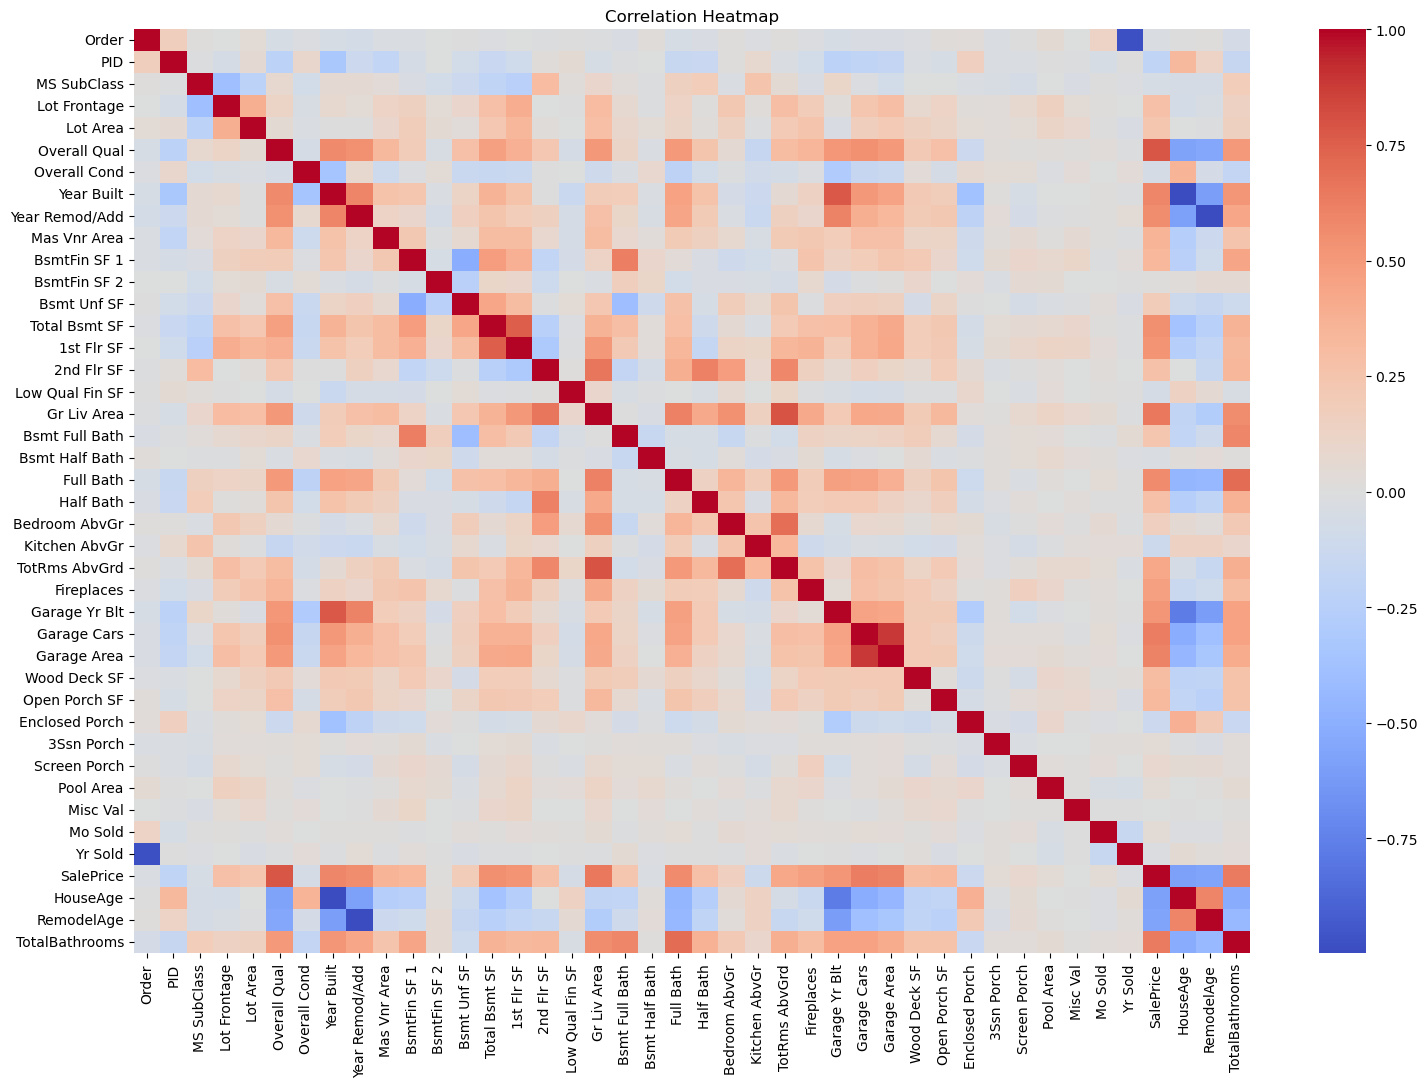

In [32]:
plt.figure(figsize=(18,12))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [33]:
corr["SalePrice"].sort_values(ascending=False)

SalePrice          1.000000
Overall Qual       0.785878
Gr Liv Area        0.652255
TotalBathrooms     0.633780
Garage Cars        0.631196
Garage Area        0.605579
Year Built         0.592549
Full Bath          0.565246
Year Remod/Add     0.562002
Total Bsmt SF      0.549660
1st Flr SF         0.531070
Garage Yr Blt      0.518461
Fireplaces         0.462706
TotRms AbvGrd      0.428873
Mas Vnr Area       0.354364
BsmtFin SF 1       0.330764
Open Porch SF      0.316121
Wood Deck SF       0.302856
Lot Frontage       0.276145
Half Bath          0.275136
2nd Flr SF         0.270606
Lot Area           0.241337
Bsmt Full Bath     0.236646
Bsmt Unf SF        0.190383
Bedroom AbvGr      0.159237
Screen Porch       0.086022
Pool Area          0.045809
3Ssn Porch         0.042738
Mo Sold            0.039737
BsmtFin SF 2       0.011301
Misc Val          -0.003627
Yr Sold           -0.016148
Bsmt Half Bath    -0.023888
Order             -0.029564
MS SubClass       -0.053960
Low Qual Fin SF   -0

In [34]:
top_features = corr["SalePrice"].abs().sort_values(ascending=False).head(20)

top_features

SalePrice         1.000000
Overall Qual      0.785878
Gr Liv Area       0.652255
TotalBathrooms    0.633780
Garage Cars       0.631196
Garage Area       0.605579
Year Built        0.592549
HouseAge          0.592428
Full Bath         0.565246
RemodelAge        0.563306
Year Remod/Add    0.562002
Total Bsmt SF     0.549660
1st Flr SF        0.531070
Garage Yr Blt     0.518461
Fireplaces        0.462706
TotRms AbvGrd     0.428873
Mas Vnr Area      0.354364
BsmtFin SF 1      0.330764
Open Porch SF     0.316121
Wood Deck SF      0.302856
Name: SalePrice, dtype: float64

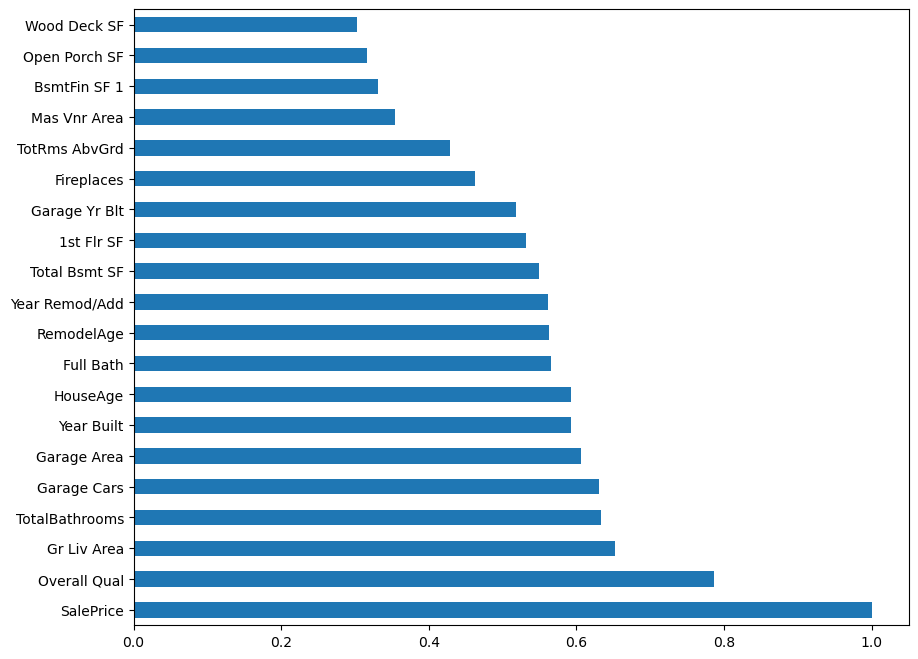

In [35]:
plt.figure(figsize=(10,8))

top_features.plot(kind="barh")

plt.show()

# Feature Engineering

In this section we will

1. Create New Features
2. Encode Categorical Variables
3. Correlation Analysis
4. Feature Selection
5. Train-Test Split
6. Feature Scaling

In [36]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['MS Zoning', 'Street', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Exter Qual', 'Exter Cond',
       'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',
       'Paved Drive', 'Sale Type', 'Sale Condition'],
      dtype='object')

In [37]:
df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

In [38]:
df.isnull().sum().sum()

0

In [47]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [45]:
X = df.drop("SalePrice",axis=1)

y = df["SalePrice"]

In [49]:
from sklearn.preprocessing import StandardScaler

In [51]:
scaler=StandardScaler()

In [53]:
X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [55]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(2234, 247)
(559, 247)
(2234,)
(559,)


### # Model Building

We will train the following models:

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. Decision Tree Regressor
5. Random Forest Regressor
6. Gradient Boosting Regressor

In [59]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [60]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [63]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, y_pred)

    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE :", rmse)
    print("R2 Score :", r2)

    return mae, mse, rmse, r2

In [65]:
linear = LinearRegression()

linear_mae, linear_mse, linear_rmse, linear_r2 = evaluate_model(
    linear,
    X_train,
    X_test,
    y_train,
    y_test
)

MAE : 30101998134.0119
MSE : 2.6204982347226568e+23
RMSE : 511908022473.04706
R2 Score : -70462048936205.4


In [66]:
ridge = Ridge(alpha=1.0)

ridge_mae, ridge_mse, ridge_rmse, ridge_r2 = evaluate_model(
    ridge,
    X_train,
    X_test,
    y_train,
    y_test
)

MAE : 14140.44456049423
MSE : 1066697096.4491751
RMSE : 32660.3290927874
R2 Score : 0.7131779674025773


In [67]:
lasso = Lasso(alpha=0.001)

lasso_mae, lasso_mse, lasso_rmse, lasso_r2 = evaluate_model(
    lasso,
    X_train,
    X_test,
    y_train,
    y_test
)

MAE : 14196.084817426705
MSE : 1117963823.8703918
RMSE : 33435.96602268868
R2 Score : 0.6993929603818217


In [68]:
tree = DecisionTreeRegressor(random_state=42)

tree_mae, tree_mse, tree_rmse, tree_r2 = evaluate_model(
    tree,
    X_train,
    X_test,
    y_train,
    y_test
)

MAE : 20485.760286225403
MSE : 892194706.1896243
RMSE : 29869.628490987703
R2 Score : 0.7600995634526306


In [69]:
forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

forest_mae, forest_mse, forest_rmse, forest_r2 = evaluate_model(
    forest,
    X_train,
    X_test,
    y_train,
    y_test
)

MAE : 14053.641976744186
MSE : 424999514.03569144
RMSE : 20615.5163417192
R2 Score : 0.8857227371533939


In [72]:
forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

forest_mae, forest_mse, forest_rmse, forest_r2 = evaluate_model(
    forest,
    X_train,
    X_test,
    y_train,
    y_test
)

MAE : 14053.641976744186
MSE : 424999514.03569144
RMSE : 20615.5163417192
R2 Score : 0.8857227371533939


In [73]:
gbr = GradientBoostingRegressor(random_state=42)

gbr_mae, gbr_mse, gbr_rmse, gbr_r2 = evaluate_model(
    gbr,
    X_train,
    X_test,
    y_train,
    y_test
)

MAE : 12830.184456210693
MSE : 340520076.0733437
RMSE : 18453.186068355342
R2 Score : 0.9084382429794688


In [74]:
results = pd.DataFrame({

'Model':[
'Linear Regression',
'Ridge',
'Lasso',
'Decision Tree',
'Random Forest',
'Gradient Boosting'
],

'MAE':[
linear_mae,
ridge_mae,
lasso_mae,
tree_mae,
forest_mae,
gbr_mae
],

'RMSE':[
linear_rmse,
ridge_rmse,
lasso_rmse,
tree_rmse,
forest_rmse,
gbr_rmse
],

'R2 Score':[
linear_r2,
ridge_r2,
lasso_r2,
tree_r2,
forest_r2,
gbr_r2
]

})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,3.010200e+10,5.119080e+11,-7.046205e+13
1,Ridge,1.414044e+04,3.266033e+04,7.131780e-01
2,Lasso,1.419608e+04,3.343597e+04,6.993930e-01
3,Decision Tree,2.048576e+04,2.986963e+04,7.600996e-01
4,Random Forest,1.405364e+04,2.061552e+04,8.857227e-01
5,Gradient Boosting,1.283018e+04,1.845319e+04,9.084382e-01


In [77]:
results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
5,Gradient Boosting,1.283018e+04,1.845319e+04,9.084382e-01
4,Random Forest,1.405364e+04,2.061552e+04,8.857227e-01
3,Decision Tree,2.048576e+04,2.986963e+04,7.600996e-01
1,Ridge,1.414044e+04,3.266033e+04,7.131780e-01
2,Lasso,1.419608e+04,3.343597e+04,6.993930e-01
0,Linear Regression,3.010200e+10,5.119080e+11,-7.046205e+13


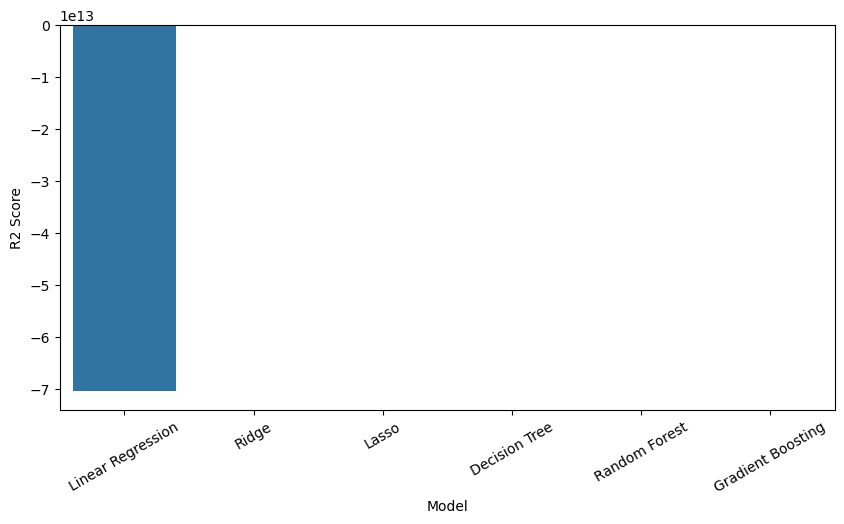

In [78]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)

plt.xticks(rotation=30)

plt.show()

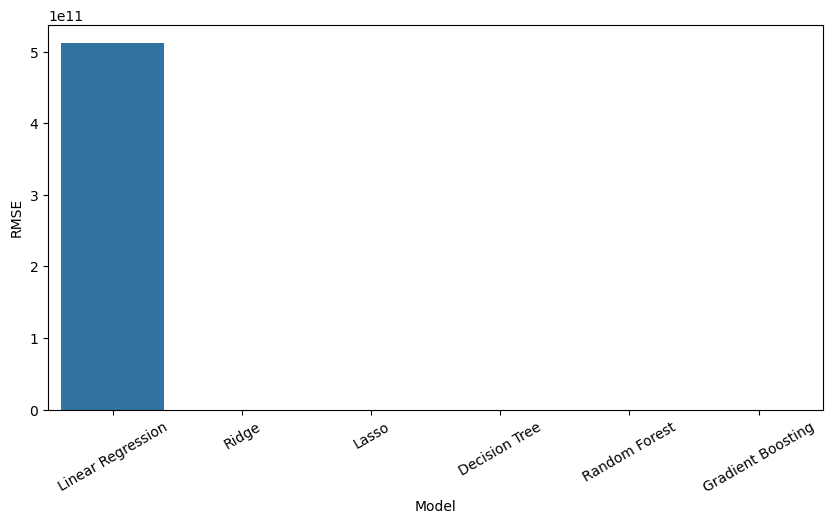

In [79]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Model",
    y="RMSE"
)

plt.xticks(rotation=30)

plt.show()

In [80]:
best_model = forest

best_model

RandomForestRegressor(n_estimators=200, random_state=42)

In [81]:
y_pred = best_model.predict(X_test)

In [82]:
comparison = pd.DataFrame({

'Actual':y_test,

'Predicted':y_pred

})

comparison.head(20)

,Actual,Predicted
2788,137000,155093.785
1314,129400,129865.585
2818,102000,113896.010
150,122500,125028.615
220,125000,123318.705
1161,178000,185284.635
2836,81000,95113.875
603,177625,168872.750
1579,150000,175148.025
867,198500,196446.240


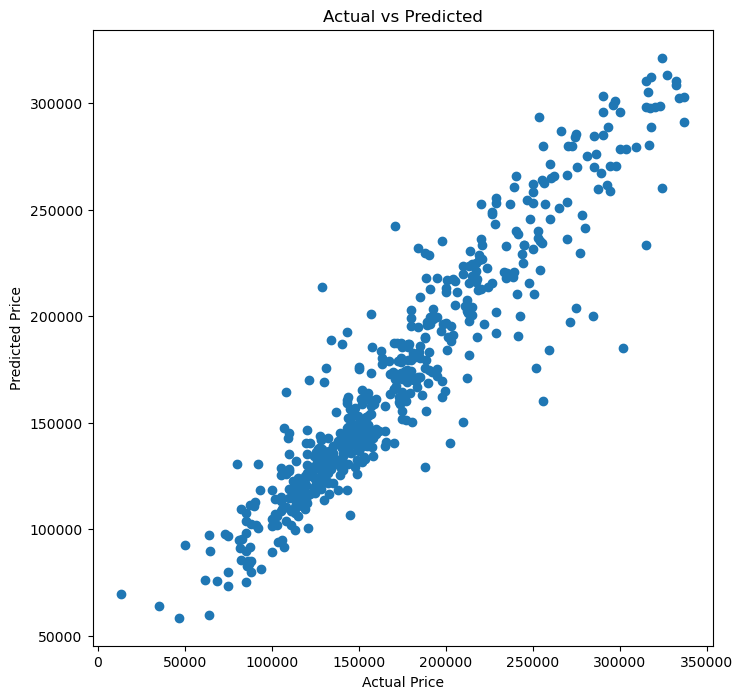

In [83]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

In [84]:
residuals = y_test - y_pred

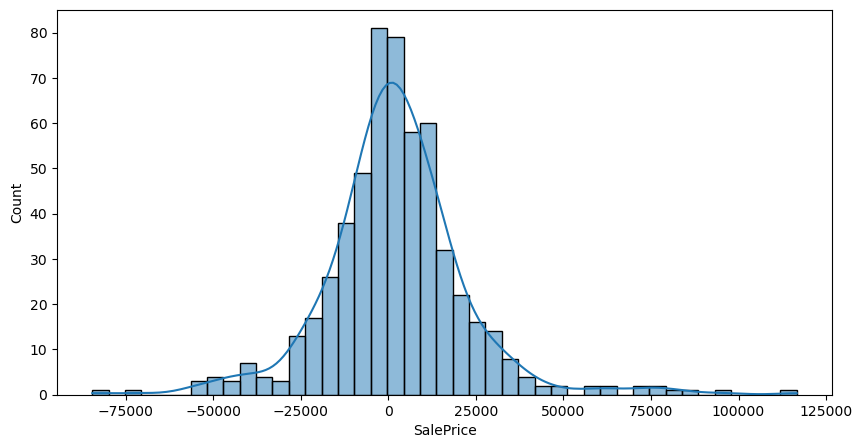

In [86]:
plt.figure(figsize=(10,5))

sns.histplot(
    residuals,
    kde=True
)

plt.show()

In [87]:
importance = pd.DataFrame({

'Feature':X.columns,

'Importance':best_model.feature_importances_

})

importance.head()

,Feature,Importance
0,Order,0.003638
1,PID,0.006855
2,MS SubClass,0.002899
3,Lot Frontage,0.004669
4,Lot Area,0.018103


In [88]:
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(20)

,Feature,Importance
5,Overall Qual,0.540591
17,Gr Liv Area,0.086652
40,TotalBathrooms,0.063152
13,Total Bsmt SF,0.051502
28,Garage Area,0.043154
14,1st Flr SF,0.028204
4,Lot Area,0.018103
27,Garage Cars,0.016224
10,BsmtFin SF 1,0.014283
15,2nd Flr SF,0.007294


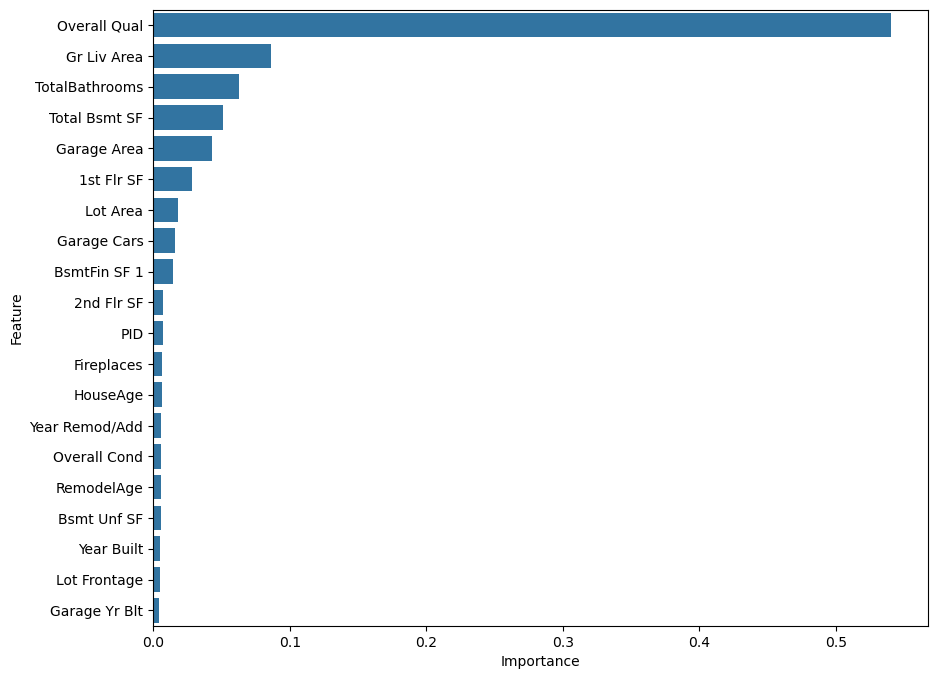

In [89]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x='Importance',
    y='Feature'
)

plt.show()

In [90]:
from sklearn.model_selection import cross_val_score

In [91]:
scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

scores

array([0.88121168, 0.90094444, 0.87178562, 0.84994076, 0.89001361])

In [93]:
print("Average CV Score :",scores.mean())

Average CV Score : 0.8787792222050121


In [94]:
import pickle

In [97]:
pickle.dump(best_model,
            open("HousePricePrediction.pkl","wb"))

In [99]:
loaded_model = pickle.load(
    open("HousePricePrediction.pkl","rb")
)

In [103]:
prediction = loaded_model.predict(X_test[:5])

prediction

array([155093.785, 129865.585, 113896.01 , 125028.615, 123318.705])

# Hyperparameter Tuning

In [133]:
from sklearn.model_selection import GridSearchCV

In [135]:
params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [137]:
grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [139]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [140]:
grid.best_params_

{'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

In [150]:
best_rf = grid.best_estimator_

In [152]:
best_rf.score(X_test, y_test)

0.8857227371533939

In [155]:
from sklearn.model_selection import learning_curve

In [157]:
train_sizes, train_scores, test_scores = learning_curve(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

In [158]:
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

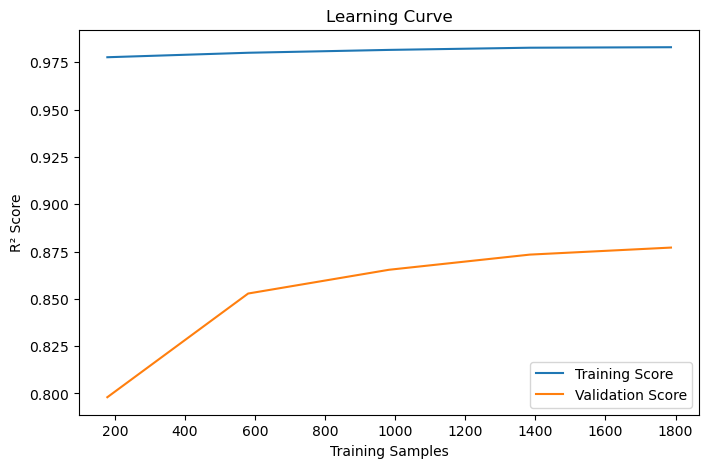

In [160]:
plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")

plt.xlabel("Training Samples")
plt.ylabel("R² Score")
plt.title("Learning Curve")
plt.legend()

plt.show()

In [161]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [162]:
feature_importance.head(15)

,Feature,Importance
5,Overall Qual,0.540591
17,Gr Liv Area,0.086652
40,TotalBathrooms,0.063152
13,Total Bsmt SF,0.051502
28,Garage Area,0.043154
14,1st Flr SF,0.028204
4,Lot Area,0.018103
27,Garage Cars,0.016224
10,BsmtFin SF 1,0.014283
15,2nd Flr SF,0.007294


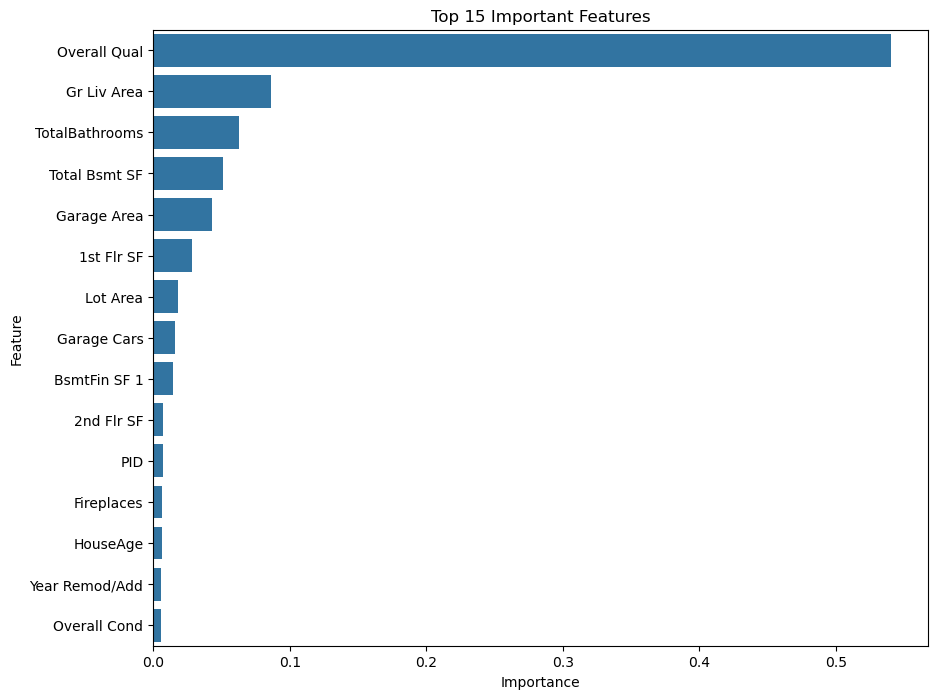

In [163]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Important Features")

plt.show()

In [164]:
pickle.dump(
    scaler,
    open("scaler.pkl", "wb")
)

In [165]:
loaded_scaler = pickle.load(
    open("scaler.pkl", "rb")
)

In [166]:
sample_house = X.iloc[[0]]

sample_house_scaled = loaded_scaler.transform(sample_house)

predicted_price = best_rf.predict(sample_house_scaled)

print("Predicted Price:", predicted_price[0])

Predicted Price: 203380.66


In [167]:
print("Model Used : Random Forest")

print("R² Score :", r2_score(y_test, best_rf.predict(X_test)))

print("RMSE :", np.sqrt(mean_squared_error(y_test, best_rf.predict(X_test))))

print("MAE :", mean_absolute_error(y_test, best_rf.predict(X_test)))

Model Used : Random Forest
R² Score : 0.8857227371533939
RMSE : 20615.5163417192
MAE : 14053.641976744186


# Project Completed

✔ Dataset Cleaning

✔ Feature Engineering

✔ Exploratory Data Analysis

✔ Linear Regression

✔ Ridge Regression

✔ Lasso Regression

✔ Decision Tree

✔ Random Forest

✔ Gradient Boosting

✔ Hyperparameter Tuning

✔ Cross Validation

✔ Learning Curve

✔ Feature Importance

✔ Model Saving

✔ Prediction

Project Status : Completed

In [ ]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")
tags = pd.read_csv("tags.csv")
links = pd.read_csv("links.csv")